## Exploratory Data Analysis on the raw data

In [87]:
# Import all the desired packages and libraries
import os

import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Image

import warnings
warnings.filterwarnings("ignore")


- Load raw data from local directory

In [88]:
DATA_DIR = "EPL_2025"

def load_match_data(data_path: str = DATA_DIR):
    unique_teams = set()
    match_data = []
    shots_data = []

    for dirpath, dirnames, filenames in os.walk(data_path):
        if "context.json" in filenames and "shots.json" in filenames:
            try:
                with open(os.path.join(dirpath, "context.json"), "r") as f:
                    context = json.load(f)
                with open(os.path.join(dirpath, "shots.json"), "r") as f:
                    shots = json.load(f)
                
                # Extract relevant data from context and shots files
                home_team = context.get("team_h")
                away_team = context.get("team_a")

                # home_shots_raw = shots.get("h", [])
                # away_shots_raw = shots.get("a", [])

                # home_shots = {
                #     "minute": [shot.get("minute") for shot in home_shots_raw],
                #     "result": [shot.get("result") for shot in home_shots_raw],
                #     "xG": [shot.get("xG") for shot in home_shots_raw],
                #     "player": [shot.get("player") for shot in home_shots_raw],
                # }

                # away_shots = {
                #     "minute": [shot.get("minute") for shot in away_shots_raw],
                #     "result": [shot.get("result") for shot in away_shots_raw],
                #     "xG": [shot.get("xG") for shot in away_shots_raw],
                #     "player": [shot.get("player") for shot in away_shots_raw],
                # }
                
                match_data.append({
                    "home_team": home_team,
                    "away_team": away_team,
                    "h_goals": int(context.get("h_goals")),
                    "a_goals": int(context.get("a_goals")),
                    "h_shot": int(context.get("h_shot")),
                    "a_shot": int(context.get("a_shot")),
                    "h_xg": float(context.get("h_xg")),
                    "a_xg": float(context.get("a_xg")),
                    "h_shotOnTarget": int(context.get("h_shotOnTarget")),
                    "a_shotOnTarget": int(context.get("a_shotOnTarget")),
                    "h_ppda": float(context.get("h_ppda")),
                    "a_ppda": float(context.get("a_ppda")),
                    # "h_shots": home_shots,
                    # "a_shots": away_shots
                })
                unique_teams.add(home_team)
                unique_teams.add(away_team)

                for shot in shots.get("h", []):
                    shots_data.append({
                        "match_id": shot.get("match_id"),
                        "team": home_team,
                        "opponent": away_team,
                        "minute": int(shot.get("minute")),
                        "result": shot.get("result"),
                        "xG": float(shot.get("xG")),
                        "player": shot.get("player"),
                        "h_a": shot.get("h_a"),
                        "h_goals": int(context.get("h_goals")),
                        "a_goals": int(context.get("a_goals")),
                        "shotType": shot.get("shotType")
                        })
                for shot in shots.get("a", []):
                    shots_data.append({
                        "match_id": shot.get("match_id"),
                        "team": away_team,
                        "opponent": home_team,
                        "minute": int(shot.get("minute")),
                        "result": shot.get("result"),
                        "xG": float(shot.get("xG")),
                        "player": shot.get("player"),
                        "h_a": shot.get("h_a"),
                        "h_goals": int(context.get("h_goals")),
                        "a_goals": int(context.get("a_goals")),
                        "shotType": shot.get("shotType")
                        })
            except Exception as e:
                print(f"Error loading data from {dirpath}: {e}")

    sorted_teams = sorted(list(unique_teams))
    match_data = pd.DataFrame(match_data)
    shots_data = pd.DataFrame(shots_data)

    return sorted_teams, match_data, shots_data

teams, match_data, shots_data = load_match_data(DATA_DIR)
# if teams:
#     print(f"Loaded {len(teams)} unique teams: {teams}")
# if not match_data.empty:
#     print(f"Loaded {len(match_data)} matches.")
#     print(f"Sample data:\n{match_data.iloc[0]}")
# if not shots_data.empty:
#     print(f"Loaded {len(shots_data)} shots.")
#     print(f"Sample data:\n{shots_data.iloc[0]}")


In [91]:
print(f"match_data_shape: {match_data.shape}")
print(f"match_data:\n{match_data.head()}")

print(f"Shots_data_shape: {shots_data.shape}")
print(f"Shots_data:\n{shots_data.head()}")

match_data_shape: (370, 12)
match_data:
     home_team         away_team  h_goals  a_goals  h_shot  a_shot      h_xg  \
0    Liverpool       Bournemouth        4        2      19      10  2.330070   
1  Aston Villa  Newcastle United        0        0       3      16  0.318601   
2     Brighton            Fulham        1        1      10       7  1.440080   
3   Sunderland          West Ham        3        0      10      12  0.724368   
4    Tottenham           Burnley        3        0      16      14  1.978580   

       a_xg  h_shotOnTarget  a_shotOnTarget   h_ppda   a_ppda  
0  1.573030              10               3   8.7647  11.5833  
1  1.400980               3               3  18.9167   6.0833  
2  0.902883               4               2   8.9286  16.2222  
3  0.558948               5               4  20.7857  11.0000  
4  0.734138               6               4   6.3529  17.3529  
Shots_data_shape: (9232, 11)
Shots_data:
  match_id       team     opponent  minute       resul

- Select a team for Exploratory Data Analysis (EDA)

In [ ]:
team_selector = widgets.Dropdown(
    options=teams,
    value=None if teams else None,
    description="Select a team for EDA:",
    disabled=not bool(teams),
    style={"description_width": "initial"}
)

canvas_output = widgets.Output()


def plot_team_xg_distribution(team, df, save=False):
    # Helper function to plot the xG distribution for a team.
    team_df = df[(df["home_team"] == team) | (df["away_team"] == team)]
    home_xgs = list(team_df.loc[team_df["home_team"] == team, "h_xg"].astype(float))
    away_xgs = list(team_df.loc[team_df["away_team"] == team, "a_xg"].astype(float))
    fig, ax = plt.subplots(figsize=(7,3))
    sns.histplot(home_xgs, bins=10, kde=False)
    sns.histplot(away_xgs, bins=10, kde=False)
    plt.title(f"fontdict={team} xG distribution per match")
    plt.xlabel("xG")
    plt.ylabel("Matches")
    plt.legend(["Home", "Away"])
    fig.tight_layout()
    # display(fig)

    if save:
        filename = f"{team.replace(' ', '_').lower()}_xg_distribution.png"
        fig.savefig(filename, dpi=150, bbox_inches="tight")
    return fig
    


def plot_team_shots_xg(team, shots_df, save=False):
    # Select all shot data for matches involving 'team'
    df = shots_df[(shots_df["team"] == team)]
    if df.empty:
        print(f"No shots found for {team}")
        return
    

    team_shots = df.dropna(subset=["minute", "xG"])
    display(f"Found {len(team_shots)} shots for {team} in {len(df.drop_duplicates('match_id'))} matches")
    # display(team_shots)

    fig, ax = plt.subplots(figsize=(7,3))
    ax.scatter(team_shots["minute"], team_shots["xG"])
    ax.set_xlabel("Minute")
    ax.set_ylabel("xG")
    ax.set_title(f"{team} Shots xG by Minute")
    fig.tight_layout()
    # display(fig)

    if save:
        filename = f"{team.replace(' ', '_').lower()}_shot_xg.png"
        fig.savefig(filename, dpi=150, bbox_inches="tight")
    
    return fig



def dropdown_handler(change):
    new_team = change["new"]
    with canvas_output:
        if new_team not in teams:
            display(f"Invalid team selected: {new_team}")
            return
        
        canvas_output.clear_output()
        display(f"Performing EDA for {new_team}")
        xg_distribution_fig = plot_team_xg_distribution(new_team, match_data, save=False)
        shots_xg_fig = plot_team_shots_xg(new_team, shots_data, save=False)
        if xg_distribution_fig is not None:
            display(xg_distribution_fig)
            plt.close(xg_distribution_fig)
        if shots_xg_fig is not None:
            display(shots_xg_fig)
            plt.close(shots_xg_fig)

try:
    team_selector.unobserve(dropdown_handler, names="value")
except ValueError:
    pass

team_selector.observe(dropdown_handler, names="value")

display(widgets.VBox([team_selector, canvas_output]))

In [36]:
# Save the EDA plots
# display(Image(filename="manchester_united_xg_distribution.png"))
# display(Image(filename="manchester_united_shot_xg.png"))

### Lets look at the xG by game state.
- If a team is leading a match, what is the distribution of aggregate xG?
- What if the match is tied?

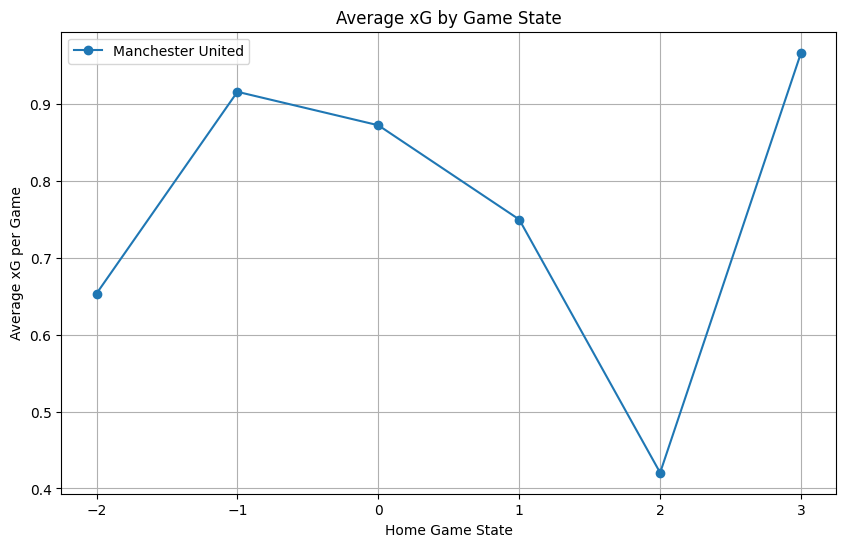

In [ ]:
# Add game_state features to the dataset
def add_game_state(shots_data):
    # Add score before each shot (game_state = home_goals - away_goals) for each shot data.
    # 'game_state' +ve means home team is winning, -ve means away team is winning, and 0 means the game is tied.
    df = shots_data.copy()

    # The h_goals and a_goals are the final score for each shot in the data. To fix this, I will add
    # new columns called home_goals and away_goals to store the score leading up to each shot.

    # Sorting dataframe by minute
    df["minute"] = pd.to_numeric(df["minute"], errors='coerce')

    df["current_home_goals"] = 0
    df["current_away_goals"] = 0
    df["home_game_state"] = 0
    df["away_game_state"] = 0

    for match, match_shots in df.groupby("match_id"):
        match_shots = match_shots.sort_values("minute").copy()

        home_goals = 0
        away_goals = 0
        
        for idx, shot in match_shots.iterrows():
            # Update the game state for this shot
            df.loc[idx, "current_home_goals"] = home_goals
            df.loc[idx, "current_away_goals"] = away_goals
            df.loc[idx, "home_game_state"] = home_goals - away_goals
            df.loc[idx, "away_game_state"] = away_goals - home_goals

            if shot["result"] == "Goal":
                if shot["h_a"] == "h":
                    home_goals += 1
                elif shot["h_a"] == "a":
                    away_goals += 1

    return df




def calculate_avg_xg_by_game_state(shots_data_with_game_state):
    team_game_state_xg = shots_data_with_game_state.groupby(["team", "match_id", "home_game_state"], as_index=False).agg(
        total_xG=("xG", "sum"), shots=("xG", "count"))

    # Average across all matches for each team
    avg_xg_state = team_game_state_xg.groupby(["team", "home_game_state"], as_index=False).agg(
        avg_xg_per_game=("total_xG", "mean"),
        matches=("match_id", "nunique"))
    return avg_xg_state



shots_data_with_game_state = add_game_state(shots_data)
# print(shots_data_with_game_state.head(10))
avg_xg_by_state = calculate_avg_xg_by_game_state(shots_data_with_game_state)
# print(avg_xg_by_state.head(20))


def plot_avg_xg_by_game_state(avg_xg_by_state, team):    
    fig, ax = plt.subplots(figsize=(10, 6))
    team_data = avg_xg_by_state[avg_xg_by_state["team"] == team]
    plt.plot(team_data["home_game_state"], team_data["avg_xg_per_game"], marker='o', label=team)
    
    plt.xlabel("Home Game State")
    plt.ylabel("Average xG per Game")
    plt.title("Average xG by Game State")
    plt.legend()
    plt.grid(True)
    plt.show()


# Test the function with a specific team
plot_avg_xg_by_game_state(avg_xg_by_state, "Manchester United")